In [2]:
import pandas as pd
import numpy as np
 
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

In [3]:
url = 'https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv'
# !wget $url

In [4]:
data = pd.read_csv("car_fuel_efficiency.csv")
df = data.copy()
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [5]:
df.shape

(9704, 11)

In [6]:
df.dtypes

engine_displacement      int64
num_cylinders          float64
horsepower             float64
vehicle_weight         float64
acceleration           float64
model_year               int64
origin                  object
fuel_type               object
drivetrain              object
num_doors              float64
fuel_efficiency_mpg    float64
dtype: object

In [7]:
df.isnull().sum()

engine_displacement      0
num_cylinders          482
horsepower             708
vehicle_weight           0
acceleration           930
model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors              502
fuel_efficiency_mpg      0
dtype: int64

In [8]:
for col in df.columns:
    df[col] = df[col].fillna(0)

In [9]:
df.isnull().sum()

engine_displacement    0
num_cylinders          0
horsepower             0
vehicle_weight         0
acceleration           0
model_year             0
origin                 0
fuel_type              0
drivetrain             0
num_doors              0
fuel_efficiency_mpg    0
dtype: int64

In [10]:
df.describe().round()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,num_doors,fuel_efficiency_mpg
count,9704.0,9704.0,9704.0,9704.0,9704.0,9704.0,9704.0,9704.0
mean,200.0,4.0,139.0,3001.0,14.0,2011.0,-0.0,15.0
std,49.0,2.0,48.0,498.0,5.0,7.0,1.0,3.0
min,10.0,0.0,0.0,953.0,0.0,2000.0,-4.0,6.0
25%,170.0,2.0,124.0,2666.0,13.0,2006.0,-1.0,13.0
50%,200.0,4.0,146.0,2993.0,15.0,2012.0,0.0,15.0
75%,230.0,5.0,168.0,3335.0,16.0,2017.0,1.0,17.0
max,380.0,13.0,271.0,4739.0,24.0,2023.0,4.0,26.0


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer

df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=11)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=11)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [15]:
dv = DictVectorizer(sparse=True)
X_train = dv.fit_transform(df_train.to_dict(orient='records'))
X_val = dv.fit_transform(df_val.to_dict(orient='records'))
X_test = dv.fit_transform(df_test.to_dict(orient='records'))

# Question 1: vehicle_weight

In [16]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score

In [17]:
rg = DecisionTreeRegressor(max_depth=1, random_state=42)
rg.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [18]:
from sklearn.tree import export_text
names = dv.get_feature_names_out().tolist()
print(export_text(rg, feature_names=names))

|--- vehicle_weight <= 3003.16
|   |--- value: [16.96]
|--- vehicle_weight >  3003.16
|   |--- value: [12.96]



# Question 2: 0.45

In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error

In [20]:
rf = RandomForestRegressor(n_estimators=10, random_state=1, n_jobs=-1)
rf.fit(X_train, y_train)

,n_estimators,10
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [21]:
y_pred = rf.predict(X_val)

root_mean_squared_error(y_val, y_pred)

0.46776500227293444

# Question 3: 80

In [22]:
estimators = np.arange(10, 201, 10)
scores = []

for n in estimators:
    rf = RandomForestRegressor(n_estimators=n, random_state=1, n_jobs=-1)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_val)
    score = root_mean_squared_error(y_val, y_pred)

    scores.append((n, score))

df_scores = pd.DataFrame(scores, columns=['estimators_no', 'RMSE'])
df_scores

,estimators_no,RMSE
0,10,0.467765
1,20,0.454518
2,30,0.451660
3,40,0.449034
4,50,0.448010
5,60,0.448252
6,70,0.447735
7,80,0.447241
8,90,0.446752
9,100,0.446593


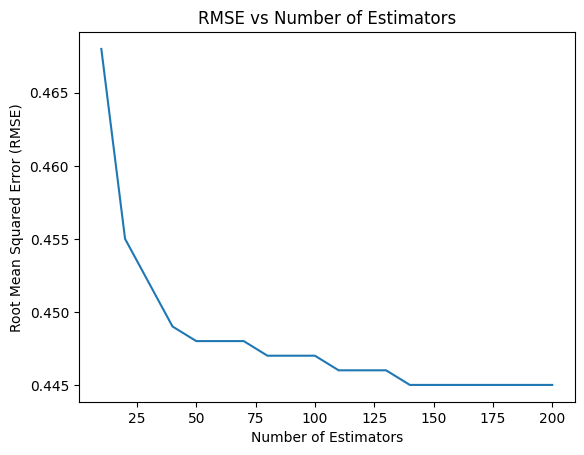

In [23]:
plt.plot(df_scores['estimators_no'], round(df_scores['RMSE'], 3))
plt.title('RMSE vs Number of Estimators')
plt.xlabel('Number of Estimators')
plt.ylabel('Root Mean Squared Error (RMSE)')
plt.show()

# Question 4: 10

In [24]:
scores = []
estimators = np.arange(10, 201, 10)

for d in [10, 15, 20, 25]:
    for n in estimators:
        rf = RandomForestRegressor(max_depth=d, n_estimators=n, random_state=1, n_jobs=-1)
        rf.fit(X_train, y_train)
    
        y_pred = rf.predict(X_val)
        rmse = root_mean_squared_error(y_val, y_pred)
    
        scores.append((d, n, rmse))

    

df_scores = pd.DataFrame(scores, columns=['max_depth', 'estimators_no', 'RMSE'])
df_scores

,max_depth,estimators_no,RMSE
0,10,10,0.459620
1,10,20,0.450409
2,10,30,0.448130
3,10,40,0.446115
4,10,50,0.445232
...,...,...,...
75,25,160,0.445132
76,25,170,0.444949
77,25,180,0.444933
78,25,190,0.445015


In [25]:
df_scores.sort_values(by='RMSE', ascending=True)

,max_depth,estimators_no,RMSE
17,10,180,0.443925
14,10,150,0.444001
18,10,190,0.444088
13,10,140,0.444103
19,10,200,0.444133
...,...,...,...
61,25,20,0.454746
0,10,10,0.459620
40,20,10,0.467148
20,15,10,0.467379


# Question 5: vehicle_weight    

In [26]:
regr = RandomForestRegressor( n_estimators=10,
                            max_depth=20,
                            random_state=1,
                            n_jobs=-1)
regr.fit(X_train, y_train)

,n_estimators,10
,criterion,'squared_error'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
feature_names = dv.get_feature_names_out().tolist()
importances = regr.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})


feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print(feature_importance)

                         Feature  Importance
13                vehicle_weight    0.961382
6                     horsepower    0.015084
0                   acceleration    0.010903
7                     model_year    0.003099
3            engine_displacement    0.003082
8                  num_cylinders    0.002210
9                      num_doors    0.001435
12                    origin=USA    0.000571
11                 origin=Europe    0.000442
10                   origin=Asia    0.000436
4               fuel_type=Diesel    0.000416
5             fuel_type=Gasoline    0.000337
2   drivetrain=Front-wheel drive    0.000321
1     drivetrain=All-wheel drive    0.000283


# Question 6: 0.1

In [37]:
import xgboost as xgb

In [38]:
features = list(dv.get_feature_names_out())
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=features)

In [40]:
%%capture output
watchlist = [(dtrain, 'train'), (dval, 'val')]

xgb_params = {
    'eta': 0.3, 
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'reg:squarederror',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round=100,
                  evals=watchlist)

In [43]:
s = output.stdout
print(s)

[0]	train-rmse:1.84404	val-rmse:1.82931
[1]	train-rmse:1.33882	val-rmse:1.33315
[2]	train-rmse:0.99374	val-rmse:0.99650
[3]	train-rmse:0.76245	val-rmse:0.77303
[4]	train-rmse:0.61172	val-rmse:0.63376
[5]	train-rmse:0.51605	val-rmse:0.54696
[6]	train-rmse:0.45777	val-rmse:0.49789
[7]	train-rmse:0.42175	val-rmse:0.47033
[8]	train-rmse:0.39875	val-rmse:0.45273
[9]	train-rmse:0.38359	val-rmse:0.44363
[10]	train-rmse:0.37405	val-rmse:0.43873
[11]	train-rmse:0.36677	val-rmse:0.43689
[12]	train-rmse:0.36123	val-rmse:0.43492
[13]	train-rmse:0.35644	val-rmse:0.43467
[14]	train-rmse:0.35255	val-rmse:0.43510
[15]	train-rmse:0.34977	val-rmse:0.43544
[16]	train-rmse:0.34688	val-rmse:0.43507
[17]	train-rmse:0.34358	val-rmse:0.43537
[18]	train-rmse:0.34052	val-rmse:0.43521
[19]	train-rmse:0.33920	val-rmse:0.43539
[20]	train-rmse:0.33639	val-rmse:0.43650
[21]	train-rmse:0.33409	val-rmse:0.43678
[22]	train-rmse:0.33237	val-rmse:0.43684
[23]	train-rmse:0.32952	val-rmse:0.43797
[24]	train-rmse:0.32796	va

In [44]:
def parse_xgb_output(output):
    results = []
 
    for line in output.stdout.strip().split('\n'):
        it_line, train_line, val_line = line.split('\t')
 
        it = int(it_line.strip('[]'))
        train = float(train_line.split(':')[1])
        val = float(val_line.split(':')[1])
 
        results.append((it, train, val))
     
    columns = ['num_iter', 'train_rmse', 'val_rmse']
    df_results = pd.DataFrame(results, columns=columns)
    return df_results

In [45]:
df_score = parse_xgb_output(output)
df_score

,num_iter,train_rmse,val_rmse
0,0,1.84404,1.82931
1,1,1.33882,1.33315
2,2,0.99374,0.99650
3,3,0.76245,0.77303
4,4,0.61172,0.63376
...,...,...,...
95,95,0.21546,0.45685
96,96,0.21300,0.45720
97,97,0.21111,0.45751
98,98,0.20903,0.45776


In [51]:
df_score.sort_values(by='val_rmse', ascending=True).iloc[0][2]

/tmp/ipykernel_596/1992290600.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_score.sort_values(by='val_rmse', ascending=True).iloc[0][2]


np.float64(0.43467)

In [52]:
%%capture output
watchlist = [(dtrain, 'train'), (dval, 'val')]

xgb_params = {
    'eta': 0.1, 
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'reg:squarederror',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round=100,
                  evals=watchlist)

In [53]:
df_score = parse_xgb_output(output)
df_score

,num_iter,train_rmse,val_rmse
0,0,2.32882,2.30796
1,1,2.10912,2.09114
2,2,1.91200,1.89641
3,3,1.73521,1.72239
4,4,1.57645,1.56641
...,...,...,...
95,95,0.31195,0.43014
96,96,0.31159,0.43033
97,97,0.31056,0.43030
98,98,0.30959,0.43035


In [54]:
df_score.sort_values(by='val_rmse', ascending=True).iloc[0][2]

/tmp/ipykernel_596/1992290600.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_score.sort_values(by='val_rmse', ascending=True).iloc[0][2]


np.float64(0.42823)